In [13]:
import pandas as pd 
import numpy as np 

In [14]:
file_path =r"C:\Users\balaj\OneDrive\Desktop\TELANGANA PDS ANALYTICS\Data\processed\monthly_unified.csv"

monthly_data = pd.read_csv(file_path)

print("monthly data shape :", monthly_data.shape)
print("monthly data first five rows and columsn :", monthly_data.head())

print("nul values",monthly_data.isna().sum())
#define the shop keys 

shop_key = ["distCode", "shopNo"]



monthly data shape : (517651, 40)
monthly data first five rows and columsn :    distCode     distName  officeCode officeName   shopNo  month  year  \
0       538  Mahbubnagar    538007.0  Koilkonda  1407001      1  2023   
1       538  Mahbubnagar    538007.0  Koilkonda  1407001      1  2024   
2       538  Mahbubnagar    538007.0  Koilkonda  1407001      1  2025   
3       538  Mahbubnagar    538007.0  Koilkonda  1407001      2  2023   
4       538  Mahbubnagar    538007.0  Koilkonda  1407001      2  2024   

   noOfRcs  noOfTrans  riceAfsc  ...                              address  \
0    241.0      241.0     805.0  ...  SANKALAMADDI ANAND KUMAR  KOILKONDA   
1    256.0      261.0    1225.0  ...  SANKALAMADDI ANAND KUMAR  KOILKONDA   
2    270.0      274.0    1120.0  ...  SANKALAMADDI ANAND KUMAR  KOILKONDA   
3    258.0      259.0     910.0  ...  SANKALAMADDI ANAND KUMAR  KOILKONDA   
4    278.0      281.0    1295.0  ...  SANKALAMADDI ANAND KUMAR  KOILKONDA   

   longitude   latitu

In [15]:
#create monthly ratios

#utilization ratio = no of trans / total rcs 

#error can stop by replacing 0 to nan 

monthly_ratio = (monthly_data["noOfTrans"]/monthly_data["totalRcs"].replace(0,np.nan)) # stored temporarily 
portability_ratio = ( monthly_data["otherShopTransCnt"] / monthly_data["noOfTrans"].replace(  0, np.nan
    )
)


rice_columns = [
    "riceAfsc",
    "riceFsc",
    "riceAap"
]

monthly_data["total_rice"]=monthly_data[rice_columns].fillna(0).sum(axis=1)#cumulative aggregation 
monthly_data["rice_wheat_rati"]= monthly_data["total_rice"]/monthly_data["wheat"].replace(0,np.nan)

print(
    monthly_data[
        [
            "utilization_ratio",
            "portability_ratio",
            "total_rice",
            "rice_wheat_ratio"
        ]
    ].isna().sum()
)


utilization_ratio     35390
portability_ratio     18003
total_rice                0
rice_wheat_ratio     479528
dtype: int64


In [16]:
# create one feature row per shop 
#converting multiple monthly records for the same shop into one summary record.
#why >> for clustering such as high-volume shops, low-volume shops , portability hubs 
#→ describe volume, stability, utilization, portability and commodity mix

shop_features  =(
    monthly_data.groupby(shop_key, as_index=False  # groupby aggregation pattern , splits dataset based on shop key
                         
)
.agg( 
    reporting_months=(
        "noOfTrans",
        "count"                                  # all following these are feature engineering
    ),
    total_transactions = (
        "noOfTrans",
        "sum"
    ),
    average_transactions=(   #typical monthly tranction 
        "noOfTrans",
        "mean"
    ),
    transaction_volatility =(
        "noOfTrans",
        "std"
    ),
    average_cards=(         #Average number of ration cards/customers
            "totalRcs",
            "mean"
        ),
 
    average_utilization=(                 #Transactions relative to eligible cards
            "utilization_ratio",
            "mean"
        ),

    average_portability_ratio=(         #Identifies portability hub
            "portability_ratio",
            "mean"
        ),

    total_portability_transactions=(
            "otherShopTransCnt",
            "sum"
        ),

    average_monthly_rice=(         #Measures rice demand/volume
            "total_rice",
            "mean"
        ),

    average_monthly_wheat=(         #Measures wheat demand/volum
            "wheat",
            "mean"
        ),

    average_rice_wheat_ratio=(
            "rice_wheat_ratio",
            "mean"
)
)
)

print(shop_features.shape)
print(shop_features.head())
print(monthly_data.shape)


(17576, 13)
   distCode   shopNo  reporting_months  total_transactions  \
0       532  1901001                29             27567.0   
1       532  1901002                29             15057.0   
2       532  1901003                29              7743.0   
3       532  1901004                29             10559.0   
4       532  1901005                29             26439.0   

   average_transactions  transaction_volatility  average_cards  \
0            950.586207               23.304686    1107.896552   
1            519.206897                7.485125     584.000000   
2            267.000000                4.735881     292.310345   
3            364.103448                3.255159     405.000000   
4            911.689655               13.164084     978.620690   

   average_utilization  average_portability_ratio  \
0             0.858004                   0.037761   
1             0.888821                   0.053426   
2             0.912903                   0.073283   
3     

In [17]:
#shop_features.isna() returns a series like missing counts , columns names 
#converting into dataframe makes earier to add, sort , print a tabulr format 



missing_report = pd.DataFrame({
    "missing_count": (
        shop_features.isna().sum()
    ),

    "missing_percentage": (
        shop_features.isna().mean()
        * 100
    ).round(2)
})

#boolean indexing where explicity reassigning into filetered version 

missing_report = missing_report[
    missing_report["missing_count"] > 0
].sort_values(
    "missing_percentage",
    ascending=False
)

print(missing_report)


model_data = shop_features[
    shop_features["reporting_months"] > 6  #Keep every shop that has at least six available monthly records.
                                            #every shop has enough obeservation4
].copy()

print(
    "All shops:",
    len(shop_features)
)

print(
    "Shops retained for clustering:",
    len(model_data)
)

print(
    "Shops excluded:",
    len(shop_features) - len(model_data)
)

mathematical_columns = [
    "average_transactions",
    "transaction_volatility",
    "average_cards",
    "average_utilization",
    "average_portability_ratio",
    "average_monthly_rice",
    "average_monthly_wheat",
    "average_rice_wheat_ratio"
]

model_data[
    mathematical_columns
].isna().sum()




                           missing_count  missing_percentage
average_rice_wheat_ratio           16065               91.40
average_transactions                  85                0.48
transaction_volatility                85                0.48
average_utilization                   85                0.48
average_portability_ratio             85                0.48
average_monthly_wheat                 85                0.48
All shops: 17576
Shops retained for clustering: 17376
Shops excluded: 200


average_transactions             0
transaction_volatility           0
average_cards                    0
average_utilization              0
average_portability_ratio        0
average_monthly_rice             0
average_monthly_wheat            0
average_rice_wheat_ratio     15882
dtype: int64

In [18]:
X = model_data[
    mathematical_columns
].copy()

# Convert infinite values into missing values
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

print("Missing values before filling:")

print(
    X.isna().sum()
)

Missing values before filling:
average_transactions             0
transaction_volatility           0
average_cards                    0
average_utilization              0
average_portability_ratio        0
average_monthly_rice             0
average_monthly_wheat            0
average_rice_wheat_ratio     15882
dtype: int64


In [19]:
completely_missing_columns = (
    X.columns[
        X.isna().all()
    ].tolist()
)

print(
    "Completely missing columns:",
    completely_missing_columns
)

if completely_missing_columns:
    raise ValueError(
        "These columns contain no usable values: "
        + str(completely_missing_columns)
    )

feature_medians = X.median()

filled= X.fillna(
    feature_medians


)

print(
    "Missing values after filling:"
)

print(
    filled.isna().sum()
)

print(
    "Total missing values:",
    filled.isna().sum().sum()
)

print(
    "Infinite values:",
    np.isinf(
        filled.to_numpy()
    ).sum()
)

Completely missing columns: []
Missing values after filling:
average_transactions         0
transaction_volatility       0
average_cards                0
average_utilization          0
average_portability_ratio    0
average_monthly_rice         0
average_monthly_wheat        0
average_rice_wheat_ratio     0
dtype: int64
Total missing values: 0
Infinite values: 0


In [20]:
#confirm the modelling data 

print("Number of shops", len(model_data))
print("Feature data shop", filled.shape)
print("missing values",filled.isna().sum())
print("infinity values ",np.isinf(filled).sum().sum())

Number of shops 17376
Feature data shop (17376, 8)
missing values average_transactions         0
transaction_volatility       0
average_cards                0
average_utilization          0
average_portability_ratio    0
average_monthly_rice         0
average_monthly_wheat        0
average_rice_wheat_ratio     0
dtype: int64
infinity values  0


In [21]:
#scale the features 

from sklearn .preprocessing import StandardScaler

scaler = StandardScaler()
scaled =scaler.fit_transform(filled)


In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

evaluation_results = []

for k in range(2, 7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(
        scaled
    )

    silhouette = silhouette_score(
        scaled,
        labels,
        sample_size=min(
            3000,
            len(scaled)
        ),
        random_state=42
    )

    evaluation_results.append({
        "clusters": k,
        "inertia": model.inertia_,
        "silhouette_score": silhouette
    })

    kmeans_evaluation = pd.DataFrame(
    evaluation_results
)

kmeans_evaluation

,clusters,inertia,silhouette_score
0,2,92249.628400,0.575178
1,3,76079.460429,0.347150
2,4,63864.088791,0.342873
3,5,57438.573465,0.240089
4,6,51064.853687,0.267589


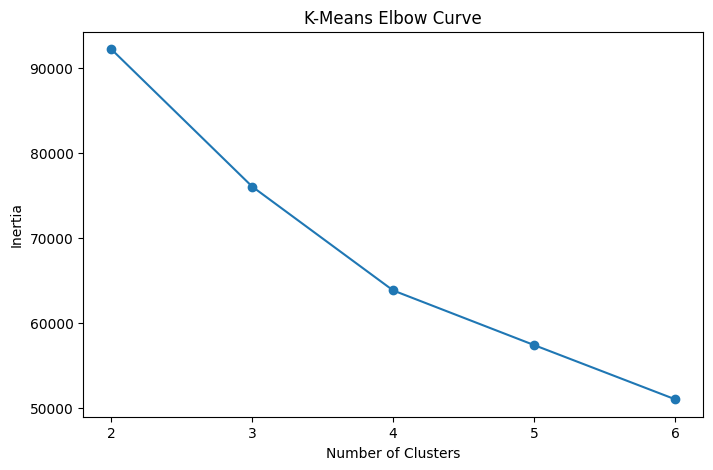

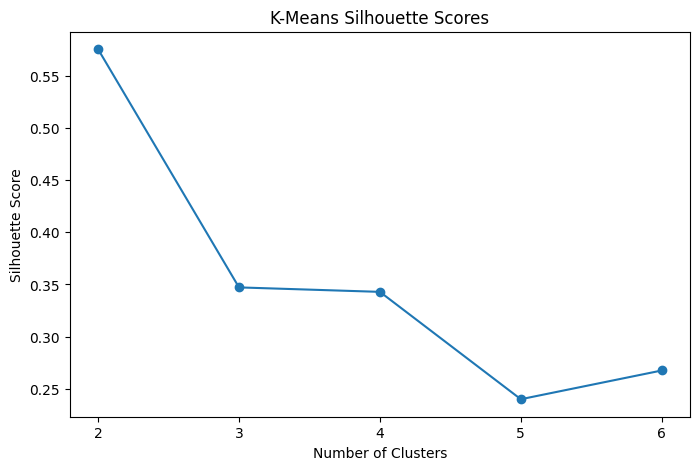

In [23]:
#PLOTTING THE ELBOW AND SILHOUETTE SORES 
#inertial decreases when k increases

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    kmeans_evaluation["clusters"],
    kmeans_evaluation["inertia"],
    marker="o"
)



plt.title("K-Means Elbow Curve")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(kmeans_evaluation["clusters"])
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    kmeans_evaluation["clusters"],
    kmeans_evaluation[
        "silhouette_score"
    ],
    marker="o"
)

plt.title("K-Means Silhouette Scores")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(kmeans_evaluation["clusters"])
plt.show()

In [24]:
kmeans_evaluation.sort_values(
    "clusters"
)

BEST_K = 4

from sklearn.cluster import KMeans

final_kmeans = KMeans(
    n_clusters=BEST_K,
    random_state=42,
    n_init=10
)

cluster_labels = (
    final_kmeans.fit_predict(
        scaled
    )
)

In [25]:
# Add labels to the shop data
model_data = model_data.reset_index(
    drop=True
)

model_data["cluster_id"] = (
    cluster_labels
)
model_data[
    [
        "distCode",
        "shopNo",
        "cluster_id"
    ]
].head()

cluster_sizes = (
    model_data["cluster_id"]
    .value_counts()
    .sort_index()
)

print(
    cluster_sizes
)

cluster_percentages = (
    model_data["cluster_id"]
    .value_counts(
        normalize=True
    )
    .sort_index()
    * 100
).round(2)

print(
    cluster_percentages
)


cluster_id
0    11125
1     5216
2        4
3     1031
Name: count, dtype: int64
cluster_id
0    64.03
1    30.02
2     0.02
3     5.93
Name: proportion, dtype: float64


Final silhouette score: 0.345


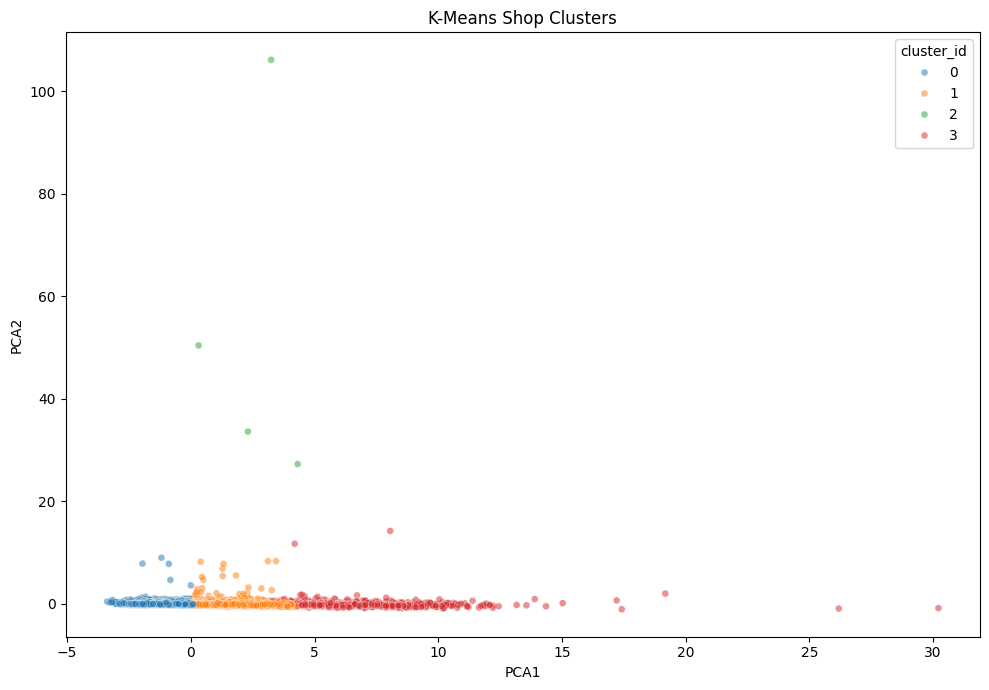

In [26]:
final_silhouette = silhouette_score(
    scaled,
    cluster_labels,
    sample_size=min(
        5000,
        len(scaled)
    ),
    random_state=42
)

print(
    "Final silhouette score:",
    round(
        final_silhouette,
        3
    )
)



#Create a PCA cluster visualization

from sklearn.decomposition import PCA

pca = PCA(
    n_components=2  #original datas converted into 2 new columns 
)

X_pca = pca.fit_transform(
    scaled
)
pca_data = pd.DataFrame({
    "PCA1": X_pca[:, 0],
    "PCA2": X_pca[:, 1],
    "cluster_id": cluster_labels
})

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_data,
    x="PCA1",
    y="PCA2",
    hue="cluster_id",
    palette="tab10",
    alpha=0.5,
    s=25
)

plt.title(
    "K-Means Shop Clusters"
)

plt.tight_layout()
plt.show()

Overall feature averages:
average_transactions          444.47
transaction_volatility         33.16
average_cards                 522.32
average_utilization             0.84
average_portability_ratio       0.28
average_monthly_rice         8796.92
average_monthly_wheat         193.51
average_rice_wheat_ratio       47.40
dtype: float64


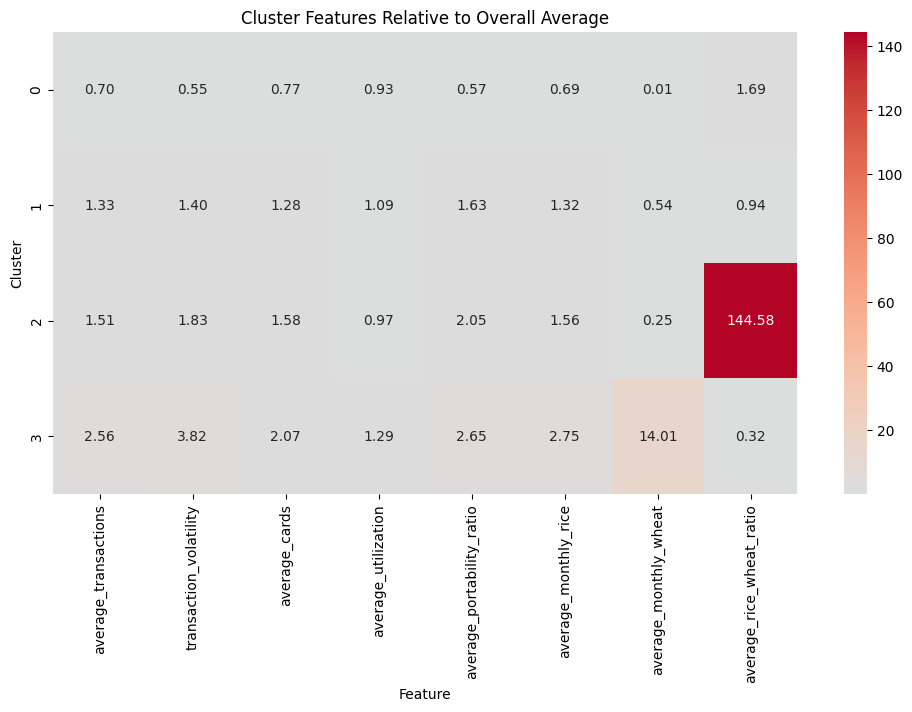

In [29]:
cluster_profiles = (
    model_data
    .groupby(
        "cluster_id"
    )[mathematical_columns]
    .mean()
    .round(2)
)

cluster_profiles


#add number of shops 

cluster_profiles[
    "number_of_shops"
] = (
    model_data
    .groupby("cluster_id")
    .size()
)

cluster_profiles.T
#Compare with the overall average
overall_average = (
    model_data[
        mathematical_columns
    ]
    .mean()
)

print(
    "Overall feature averages:"
)

print(
    overall_average.round(2)
)

#CALCULATE THE EACH CLUSTER 

relative_profiles = (
    cluster_profiles[
        mathematical_columns
    ]
    / overall_average
).round(2)

relative_profiles

#PRFILE HEATMAP

plt.figure(figsize=(12, 6))

sns.heatmap(
    relative_profiles,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=1
)

plt.title(
    "Cluster Features Relative to Overall Average"
)

plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout

cluster_names = {
    0: "Stable Regular Shops",
    1: "High-Volume Shops",
    2: "Low-Utilization Shops",
    3: "Portability Hubs"
}

In [30]:
from sklearn.cluster import DBSCAN


dbscan_results = []

for eps_value in [
    0.5,
    1.0,
    1.5,
    2.0
]:

    dbscan_model = DBSCAN(
        eps=eps_value,
        min_samples=10,
        n_jobs=-1
    )

    labels = dbscan_model.fit_predict(
        scaled
    )

    number_of_clusters = len(
        set(labels) - {-1}
    )

    number_of_noise_shops = (
        labels == -1
    ).sum()

    noise_percentage = (
        number_of_noise_shops
        / len(labels)
        * 100
    )

    dbscan_results.append({
        "eps": eps_value,
        "clusters": number_of_clusters,
        "noise_shops": number_of_noise_shops,
        "noise_percentage": round(
            noise_percentage,
            2
        )
    })


    dbscan_evaluation = pd.DataFrame(
    dbscan_results
)

dbscan_evaluation


#Fit the final DBSCAN model
FINAL_EPS = 1.5

final_dbscan = DBSCAN(
    eps=FINAL_EPS,
    min_samples=10,
    n_jobs=-1
)

dbscan_labels = (
    final_dbscan.fit_predict(
        scaled
    )
)


model_data["dbscan_label"] = (
    dbscan_labels
)

model_data["is_noise"] = (
    dbscan_labels == -1
)


print(
    "DBSCAN clusters:",
    len(
        set(dbscan_labels) - {-1}
    )
)

print(
    "Noise shops:",
    model_data["is_noise"].sum()
)

print(
    "Noise percentage:",
    round(
        model_data["is_noise"].mean()
        * 100,
        2
    ),
    "%"
)

DBSCAN clusters: 1
Noise shops: 210
Noise percentage: 1.21 %


In [ ]:
#inspect unusual shops 

noise_shops = model_data[
    model_data["is_noise"]
].copy()


noise_comparison = (
    model_data
    .groupby(
        "is_noise"
    )[MODEL_COLUMNS]
    .mean()
    .round(2)
)

noise_comparison

noise_comparison = (
    model_data
    .groupby(
        "is_noise"
    )[MODEL_COLUMNS]
    .mean()
    .round(2)
)

noise_comparison

,average_transactions,transaction_volatility,average_cards,average_utilization,average_portability_ratio,average_monthly_rice,average_monthly_wheat,average_rice_wheat_ratio
is_noise,,,,,,,,
False,434.39,31.07,513.92,0.83,0.28,8574.09,169.40,17.34
True,1251.22,205.13,1204.53,1.06,0.72,26627.20,2131.12,305.39


In [ ]:
from pathlib import Path

output_folder = Path(
    r"C:\Users\balaj\OneDrive\Desktop\TELANGANA PDS ANALYTICS\data\processed"
)

output_folder.mkdir(
    parents=True,
    exist_ok=True
)

# model_data already contains distCode and shopNo
shop_cluster_results = model_data.copy()

# Remove unnecessary index column
if "index" in shop_cluster_results.columns:
    shop_cluster_results = shop_cluster_results.drop(
        columns=["index"]
    )

# Create readable cluster names
shop_cluster_results["cluster_name"] = (
    "Cluster "
    + shop_cluster_results["cluster_id"].astype(str)
)

# Save monthly data
monthly_data.to_csv(
    output_folder / "monthly_unified.csv",
    index=False
)

# Save shop-level model results
shop_cluster_results.to_csv(
    output_folder / "shop_cluster_results.csv",
    index=False
)

print("Monthly file exists:",
      (output_folder / "monthly_unified.csv").exists())

print("Shop results file exists:",
      (output_folder / "shop_cluster_results.csv").exists())

print("Shop result shape:",
      shop_cluster_results.shape)

print(
    shop_cluster_results[
        [
            "distCode",
            "shopNo",
            "cluster_id",
            "cluster_name",
            "dbscan_label",
            "is_noise"
        ]
    ].head()
)

Monthly file exists: True
Shop results file exists: True
Shop result shape: (17399, 17)
   distCode   shopNo  cluster_id cluster_name  dbscan_label  is_noise
0       532  1901001           1    Cluster 1             0     False
1       532  1901002           0    Cluster 0             0     False
2       532  1901003           0    Cluster 0             0     False
3       532  1901004           0    Cluster 0             0     False
4       532  1901005           1    Cluster 1             0     False
